# Price Exploration - What Actually Correlates With Price?

Purpose: before engineering any features, check whether each candidate signal (days-until-departure, day of week, layovers, flight duration, route) actually shows a relationship with `totalFare` in this data. We only build features that show real signal here.

Target variable: `totalFare` (what the customer pays, tax included) rather than `baseFare`.

In [1]:
%matplotlib inline
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

pl.Config.set_tbl_rows(30)
sns.set_style("whitegrid")

df = pl.read_csv("../flight_sample.csv")

df = df.with_columns([
    pl.col("searchDate").str.to_date(),
    pl.col("flightDate").str.to_date(),
])

# days-until-departure: how far in advance the booking is
df = df.with_columns(
    (pl.col("flightDate") - pl.col("searchDate")).dt.total_days().alias("daysUntilDeparture")
)

# day of week for both dates (1=Monday .. 7=Sunday)
df = df.with_columns([
    pl.col("flightDate").dt.weekday().alias("flightDayOfWeek"),
    pl.col("searchDate").dt.weekday().alias("searchDayOfWeek"),
])

# number of layovers, derived from how many segments the itinerary has
df = df.with_columns(
    (pl.col("segmentsAirlineCode").str.split("||").list.len() - 1).alias("numStops")
)

# travelDuration is ISO 8601 like "PT2H29M" -> convert to total minutes
df = df.with_columns([
    pl.col("travelDuration").str.extract(r"(\d+)H", 1).cast(pl.Int64).fill_null(0).alias("_hours"),
    pl.col("travelDuration").str.extract(r"(\d+)M", 1).cast(pl.Int64).fill_null(0).alias("_minutes"),
])
df = df.with_columns(
    (pl.col("_hours") * 60 + pl.col("_minutes")).alias("travelDurationMinutes")
).drop(["_hours", "_minutes"])

df = df.with_columns(
    (pl.col("startingAirport") + "-" + pl.col("destinationAirport")).alias("route")
)

df.select(["totalFare", "daysUntilDeparture", "flightDayOfWeek", "searchDayOfWeek", "numStops", "travelDurationMinutes", "route"]).head(5)

totalFare,daysUntilDeparture,flightDayOfWeek,searchDayOfWeek,numStops,travelDurationMinutes,route
f64,i64,i8,i8,u32,i64,str
212.6,17,2,6,1,502,"""EWR-LAX"""
549.6,35,5,5,1,446,"""LGA-LAX"""
153.6,46,4,7,0,215,"""DFW-LAX"""
347.61,36,7,6,1,433,"""LAX-ATL"""
173.6,14,2,2,0,370,"""JFK-LAX"""


## Price overview

Basic distribution of `totalFare` before looking at relationships with anything else.

shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 1.5e6      │
│ null_count ┆ 0.0        │
│ mean       ┆ 363.71835  │
│ std        ┆ 184.549327 │
│ min        ┆ 33.58      │
│ 25%        ┆ 237.6      │
│ 50%        ┆ 348.6      │
│ 75%        ┆ 458.6      │
│ max        ┆ 4923.6     │
└────────────┴────────────┘


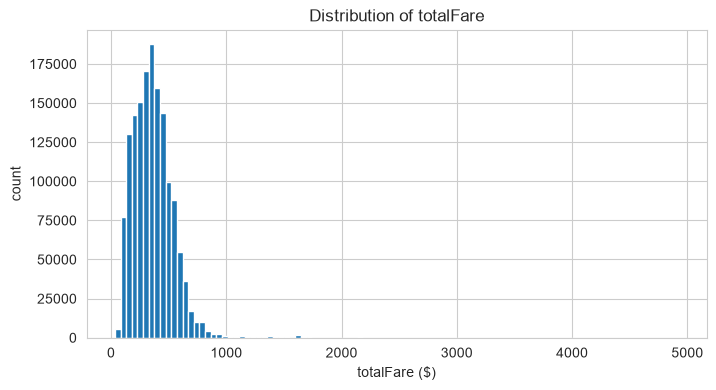

In [2]:
print(df["totalFare"].describe())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["totalFare"].to_numpy(), bins=100)
ax.set_xlabel("totalFare ($)")
ax.set_ylabel("count")
ax.set_title("Distribution of totalFare")
plt.show()

# count / null_count: 1,500,000 rows, all non-null. Confirms every row has a price (no missing target values, which matters a lot since you can't train a model to predict something it doesn't have ground truth for).

# mean ($363.72): the average — sum of all fares divided by 1.5M.

# std ($184.55): standard deviation — how spread out the prices are around that mean, on average. Roughly speaking, if this were a normal (bell-curve) distribution, about 68% of fares would fall within one std of the mean: $364 ± $185 = $179 to $549. But price data is almost never a clean bell curve (see below), so treat this as a rough sense of spread, not a precise rule.

# The percentiles (25% / 50% / 75%) are actually more trustworthy here than std, because they don't assume any particular shape:

# 25% ($237.60): a quarter of all fares are cheaper than this
# 50% / median ($348.60): half of all fares are below this, half above
# 75% ($458.60): three-quarters of all fares are cheaper than this
# The key thing to notice: mean ($364) > median ($349). When the mean sits above the median, it means the distribution is right-skewed — a long tail of expensive outliers is pulling the average up, while most flights cluster on the cheaper side. Your histogram should show a tall clump on the left and a thinning tail stretching right toward $4,923 (the max).

## Days until departure (advance booking)

intuition: how far ahead you book should matter a lot. This is `flightDate - searchDate`. Classic airline pricing theory says price is high very last-minute, dips somewhere in the middle, and can be higher very far out too (less common). Let's see if this data shows that shape.

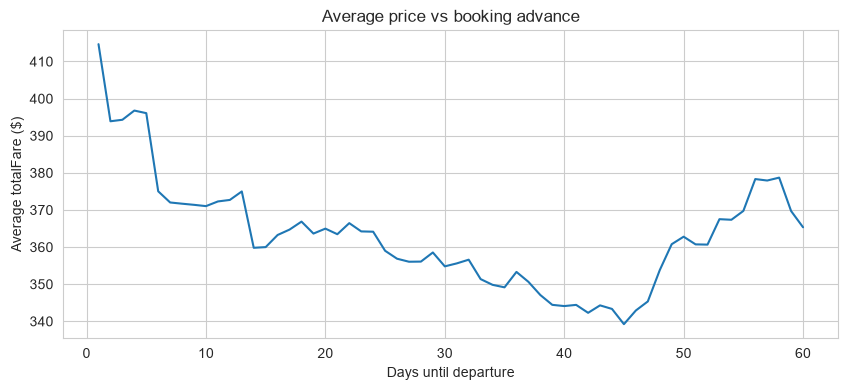

Correlation (daysUntilDeparture vs totalFare): -0.05381240954333148


In [3]:
# Step-1: Make bucket of how many advance days booking from all 1.5M rows. so all rows where people booked before 5 days fall into this bucket
# Step-2: For each bucket get the price person paid and find its avg.
# Step-3: Now for each bucket of days you have avg price so just plot it. 

by_days = (
    df.group_by("daysUntilDeparture")
    .agg(pl.col("totalFare").mean().alias("avgFare"), pl.len().alias("n"))
    .sort("daysUntilDeparture")
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(by_days["daysUntilDeparture"], by_days["avgFare"])
ax.set_xlabel("Days until departure")
ax.set_ylabel("Average totalFare ($)")
ax.set_title("Average price vs booking advance")
plt.show()

print("Correlation (daysUntilDeparture vs totalFare):", df.select(pl.corr("daysUntilDeparture", "totalFare")).item())

# -0.05 shows there is no linear correlation between days and price
# We can see somewhere at day 45 there is least price a person pays

## Day of week - flight date

Does the day you actually fly matter (e.g. Friday/Sunday often pricier due to leisure demand)?

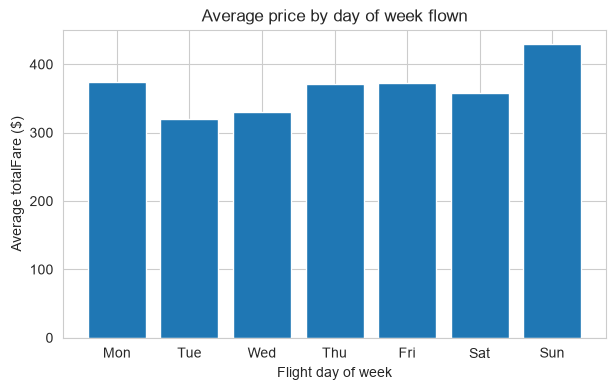

In [4]:
day_names = {1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat", 7: "Sun"}

by_flight_dow = (
    df.group_by("flightDayOfWeek")
    .agg(pl.col("totalFare").mean().alias("avgFare"))
    .sort("flightDayOfWeek")
    .with_columns(pl.col("flightDayOfWeek").replace_strict(day_names, return_dtype=pl.Utf8).alias("day"))
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(by_flight_dow["day"], by_flight_dow["avgFare"])
ax.set_xlabel("Flight day of week")
ax.set_ylabel("Average totalFare ($)")
ax.set_title("Average price by day of week flown")
plt.show()

# Clearly shows that tuesdays are cheapest

## Day of week - search date

Your intuition: prices fluctuate a bit depending on which day you search, not just which day you fly. This checks whether the day the search happened (independent of the flight day) shows any price pattern.

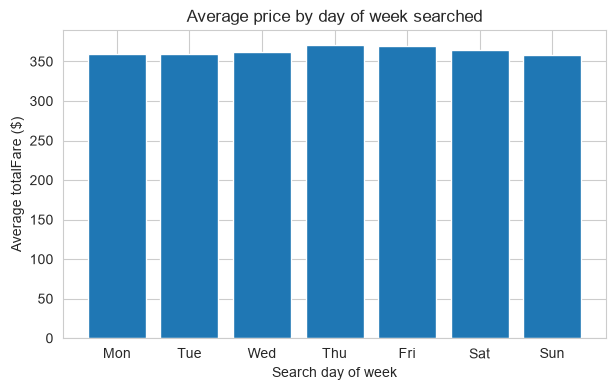

In [5]:
by_search_dow = (
    df.group_by("searchDayOfWeek")
    .agg(pl.col("totalFare").mean().alias("avgFare"))
    .sort("searchDayOfWeek")
    .with_columns(pl.col("searchDayOfWeek").replace_strict(day_names, return_dtype=pl.Utf8).alias("day"))
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(by_search_dow["day"], by_search_dow["avgFare"])
ax.set_xlabel("Search day of week")
ax.set_ylabel("Average totalFare ($)")
ax.set_title("Average price by day of week searched")
plt.show()

# Ahh so booking day doesnt affect much but flying day does affect it

## Number of layovers/stops

`numStops` = 0 for nonstop, 1 for one layover, etc, derived by counting `||`-separated segments. More stops usually means either a cheaper indirect routing or a more complex/pricier itinerary depending on the market, worth checking directly.

shape: (4, 3)
┌──────────┬────────────┬─────────┐
│ numStops ┆ avgFare    ┆ n       │
│ ---      ┆ ---        ┆ ---     │
│ u32      ┆ f64        ┆ u32     │
╞══════════╪════════════╪═════════╡
│ 0        ┆ 327.421334 ┆ 408435  │
│ 1        ┆ 375.222779 ┆ 1053048 │
│ 2        ┆ 433.787453 ┆ 38385   │
│ 3        ┆ 520.181061 ┆ 132     │
└──────────┴────────────┴─────────┘


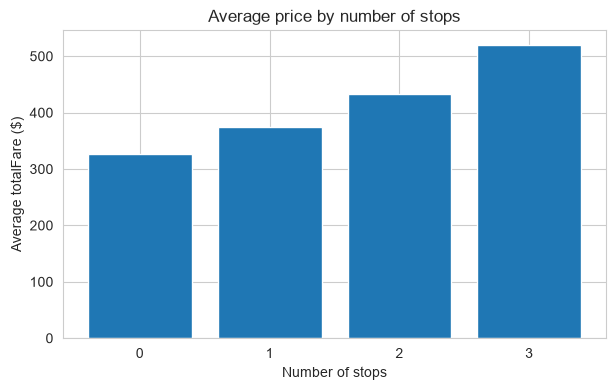

In [6]:
by_stops = (
    df.group_by("numStops")
    .agg(pl.col("totalFare").mean().alias("avgFare"), pl.len().alias("n"))
    .sort("numStops")
)
print(by_stops)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(by_stops["numStops"].cast(pl.Utf8), by_stops["avgFare"])
ax.set_xlabel("Number of stops")
ax.set_ylabel("Average totalFare ($)")
ax.set_title("Average price by number of stops")
plt.show()

## Flight duration

Total travel time in minutes, parsed from `travelDuration` (e.g. `PT2H29M`). Longer flights are usually longer distance and/or more stops, so we'd expect this to correlate with price too, possibly redundantly with distance/stops.

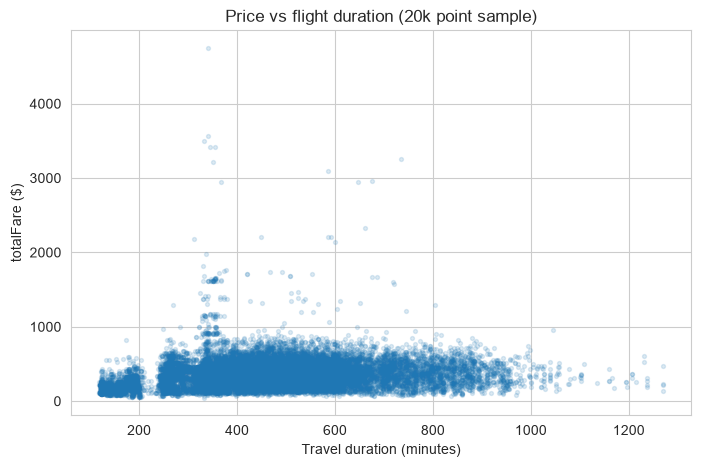

Correlation (travelDurationMinutes vs totalFare): 0.18049068472283905


In [7]:
sample_for_scatter = df.sample(n=20_000, seed=42)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(sample_for_scatter["travelDurationMinutes"], sample_for_scatter["totalFare"], alpha=0.15, s=8)
ax.set_xlabel("Travel duration (minutes)")
ax.set_ylabel("totalFare ($)")
ax.set_title("Price vs flight duration (20k point sample)")
plt.show()

print("Correlation (travelDurationMinutes vs totalFare):", df.select(pl.corr("travelDurationMinutes", "totalFare")).item())

## Route

Average price by origin-destination pair. Some routes are naturally pricier due to distance and market competition.

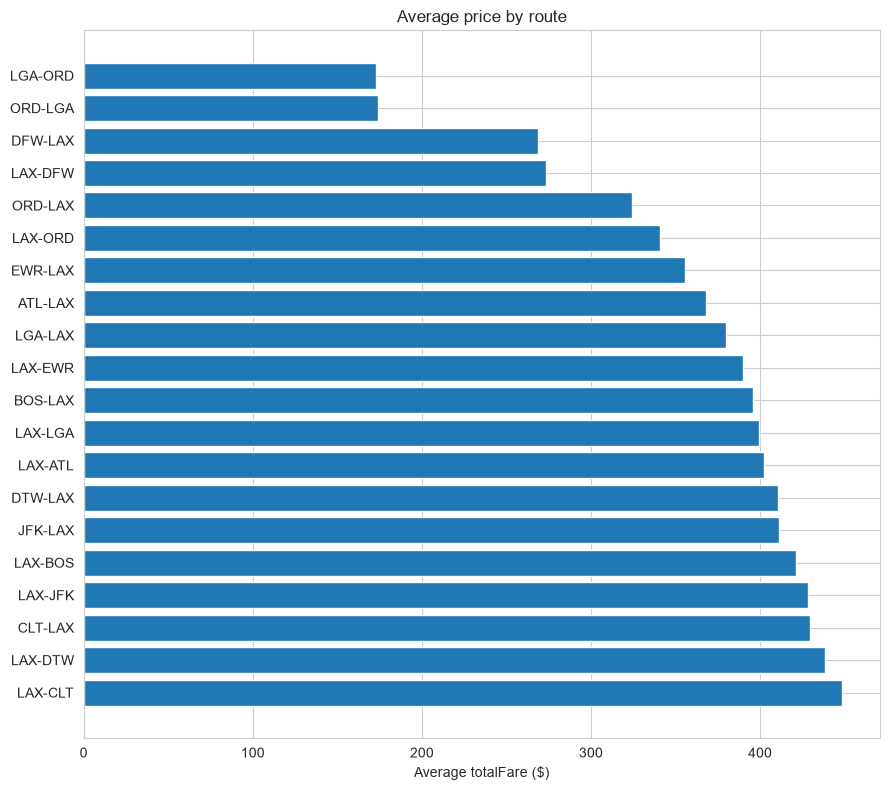

In [8]:
by_route = (
    df.group_by("route")
    .agg(pl.col("totalFare").mean().alias("avgFare"), pl.len().alias("n"))
    .sort("avgFare", descending=True)
)

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(by_route["route"], by_route["avgFare"])
ax.set_xlabel("Average totalFare ($)")
ax.set_title("Average price by route")
plt.tight_layout()
plt.show()

## Departure time of day

Does what time the flight actually leaves matter for price? Early morning and late night flights are usually cheaper (less desirable), midday/evening usually pricier (more desirable). We use `segmentsDepartureTimeRaw`, taking only the first leg's departure time (the moment the traveler actually leaves, regardless of how many stops follow).

In [9]:
# first leg's departure time only, e.g. "2022-04-17T12:57:00.000-04:00||2022-04-17T15:30:00.000-04:00" -> take the part before "||"
df = df.with_columns(
    pl.col("segmentsDepartureTimeRaw").str.split("||").list.get(0).alias("firstDepartureTimeRaw")
)

# pull the hour (00-23) straight out of the "T14:30:00..." part
df = df.with_columns(
    pl.col("firstDepartureTimeRaw").str.extract(r"T(\d{2}):", 1).cast(pl.Int64).alias("departureHour")
)

df.select(["firstDepartureTimeRaw", "departureHour"]).head(5)

firstDepartureTimeRaw,departureHour
str,i64
"""2022-09-20T06:00:00.000-04:00""",6
"""2022-07-22T09:30:00.000-04:00""",9
"""2022-11-17T06:00:00.000-06:00""",6
"""2022-09-18T13:40:00.000-07:00""",13
"""2022-09-13T17:29:00.000-04:00""",17


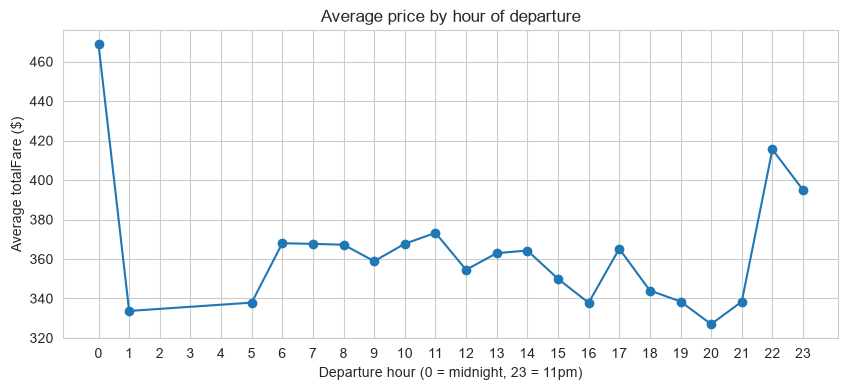

Correlation (departureHour vs totalFare): -0.008078380378968653


In [10]:
by_hour = (
    df.group_by("departureHour")
    .agg(pl.col("totalFare").mean().alias("avgFare"), pl.len().alias("n"))
    .sort("departureHour")
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(by_hour["departureHour"], by_hour["avgFare"], marker="o")
ax.set_xlabel("Departure hour (0 = midnight, 23 = 11pm)")
ax.set_ylabel("Average totalFare ($)")
ax.set_title("Average price by hour of departure")
ax.set_xticks(range(0, 24))
plt.show()

print("Correlation (departureHour vs totalFare):", df.select(pl.corr("departureHour", "totalFare")).item())

Same thing, grouped into readable buckets instead of 24 individual hours (easier to read the pattern at a glance).

shape: (4, 3)
┌───────────────────────┬────────────┬────────┐
│ timeOfDay             ┆ avgFare    ┆ n      │
│ ---                   ┆ ---        ┆ ---    │
│ enum                  ┆ f64        ┆ u32    │
╞═══════════════════════╪════════════╪════════╡
│ Late Night (12am-6am) ┆ 369.283244 ┆ 86423  │
│ Morning (6am-12pm)    ┆ 367.597951 ┆ 646623 │
│ Afternoon (12pm-6pm)  ┆ 355.723817 ┆ 447627 │
│ Evening (6pm-12am)    ┆ 365.562835 ┆ 319327 │
└───────────────────────┴────────────┴────────┘


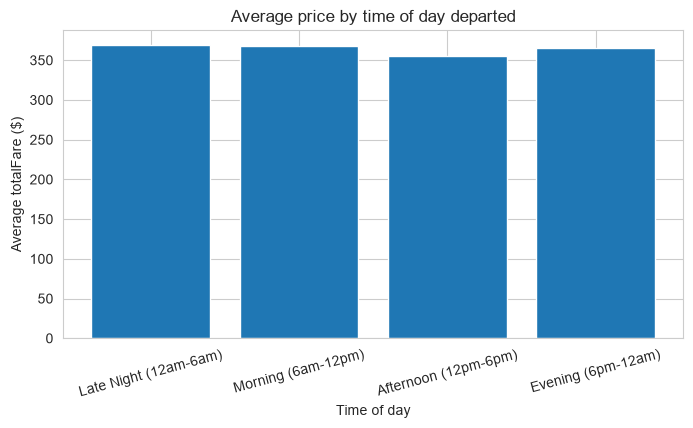

In [11]:
df = df.with_columns(
    pl.when(pl.col("departureHour").is_between(0, 5))
    .then(pl.lit("Late Night (12am-6am)"))
    .when(pl.col("departureHour").is_between(6, 11))
    .then(pl.lit("Morning (6am-12pm)"))
    .when(pl.col("departureHour").is_between(12, 17))
    .then(pl.lit("Afternoon (12pm-6pm)"))
    .otherwise(pl.lit("Evening (6pm-12am)"))
    .alias("timeOfDay")
)

time_order = ["Late Night (12am-6am)", "Morning (6am-12pm)", "Afternoon (12pm-6pm)", "Evening (6pm-12am)"]

by_timeofday = (
    df.group_by("timeOfDay")
    .agg(pl.col("totalFare").mean().alias("avgFare"), pl.len().alias("n"))
)
by_timeofday = by_timeofday.with_columns(
    pl.col("timeOfDay").cast(pl.Enum(time_order))
).sort("timeOfDay")

print(by_timeofday)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(by_timeofday["timeOfDay"].to_list(), by_timeofday["avgFare"])
ax.set_xlabel("Time of day")
ax.set_ylabel("Average totalFare ($)")
ax.set_title("Average price by time of day departed")
plt.xticks(rotation=15)
plt.show()